# Fase 2 — Flota completa N-CMAPSS: cargador multi-subconjunto + re-test de la unit 11
### TFM: Arquitectura de Mantenimiento Predictivo

Primer entregable de la Fase 2. Objetivo doble:

1. **Infraestructura:** un cargador que combine varios subconjuntos (DS01–DS08) en una sola
   flota, con **ID global de motor** (`engine_id = dataset_id + unit`) para que no colisionen
   las unidades entre ficheros, y con el **subconjunto de origen** como feature (para que el
   modelo pueda condicionar por modo de fallo).
2. **Experimento:** re-entrenar con la flota y **re-evaluar la unit 11** (DS02), para
   comprobar la hipótesis de la Fase 1: *el sesgo de la unit 11 viene de que su vida (59
   ciclos) cae fuera del rango de entrenamiento (63–89)*. Si al añadir motores de vidas
   variadas el sesgo baja, queda confirmada.

**Reutiliza el pipeline congelado de DS02:** mismas features (rolling, slope, intra-ciclo,
pos_relativa, Fc, age), misma arquitectura predecir-luego-agregar, mismo XGBoost, mismo
cap=57. Lo único nuevo es de dónde vienen los datos.

> **Necesitas los ficheros `.h5` descargados.** El notebook usa los que encuentre y avisa de
> los que falten; si solo tienes DS02, la "flota" será DS02 y el re-test saldrá igual que en
> Fase 1 (es lo esperado: sin datos nuevos no hay nada que aprender).

**Nota honesta sobre el experimento:** añadir otros subconjuntos aporta vidas más variadas,
pero también otros modos de fallo. Por eso incluimos `ds_code` como feature (el modelo puede
distinguir el subconjunto) y la lectura del resultado tendrá ese matiz en cuenta.

In [6]:
# !pip install xgboost scikit-learn h5py numpy pandas matplotlib

In [7]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
import xgboost as xgb
warnings.filterwarnings('ignore')

SEED = 42
SUBSAMPLE = 20        # con la flota completa conviene submuestrear más que en DS02 (era 10)
RUL_CAP   = 57        # cap congelado de la Fase 1 (onset físico del fallo en DS02)
ROLL_WINDOWS = (5, 10); SLOPE_W = 10
np.random.seed(SEED)

# Rutas de los ficheros: AJUSTA nombres/carpeta. Los que no existan se omiten.
FILES = {
    'DS01': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS01-005.h5',
    'DS02': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS02-006.h5',
    'DS03': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS03-012.h5',
    'DS04': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS04.h5',
    'DS05': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS05.h5',
    'DS06': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS06.h5',
    'DS07': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS07.h5',
    'DS08a': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS08a-009.h5',
    'DS08c': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS08c-008.h5',
}
# Modo de fallo por subconjunto (APROXIMADO; verifica con la doc de la NASA).
# El modelo en realidad usa ds_code, que siempre es correcto; fault_mode es solo informativo.
FAULT_MODE = {'DS01':'HPT', 'DS02':'HPT+LPT', 'DS03':'HPT+LPT', 'DS04':'Fan',
              'DS05':'HPC', 'DS06':'HPC/LPT(?)', 'DS07':'LPT', 'DS08':'all'}
DS_CODE = {name: i for i, name in enumerate(FILES)}   # subconjunto -> entero (feature)

def fault_of(name):
    return FAULT_MODE.get(name, FAULT_MODE.get(name[:4], '?'))

print('Subconjuntos configurados:', list(FILES))
print('Presentes en disco:', [n for n, p in FILES.items() if os.path.exists(p)])

Subconjuntos configurados: ['DS01', 'DS02', 'DS03', 'DS04', 'DS05', 'DS06', 'DS07', 'DS08a', 'DS08c']
Presentes en disco: ['DS01', 'DS02', 'DS03', 'DS04', 'DS05', 'DS06', 'DS07', 'DS08a', 'DS08c']


## 1. Cargador de un subconjunto

Carga W + X_s + auxiliares + Y de un split. Excluye `hs`, `X_v` y `T` (no observables).
Añade `dataset`, `engine_id` global, `ds_code` y `fault_mode`.

In [8]:
def load_subset(path, split, name):
    with h5py.File(path, 'r') as f:
        W   = np.array(f[f'W_{split}'],   dtype=np.float32)
        X_s = np.array(f[f'X_s_{split}'], dtype=np.float32)
        A   = np.array(f[f'A_{split}'],   dtype=np.float32)
        Y   = np.array(f[f'Y_{split}'],   dtype=np.float32)
        W_var  = [v.decode() for v in f['W_var'][:]]
        Xs_var = [v.decode() for v in f['X_s_var'][:]]
        A_var  = [v.decode() for v in f['A_var'][:]]
    if 'hs' in A_var:
        i = A_var.index('hs'); A = np.delete(A, i, axis=1); A_var = [v for v in A_var if v != 'hs']
    df = pd.DataFrame(np.hstack([A, W, X_s, Y.reshape(-1, 1)]),
                      columns=A_var + W_var + Xs_var + ['RUL'])
    for c in ['unit', 'cycle', 'Fc']:
        df[c] = df[c].astype(int)
    df['dataset']    = name
    df['ds_code']    = DS_CODE[name]
    df['fault_mode'] = fault_of(name)
    df['engine_id']  = name + '_u' + df['unit'].astype(str)   # ID GLOBAL: evita colisiones
    return df, W_var, Xs_var

## 2. Features (idénticas a la Fase 1, pero agrupando por `engine_id`)

La única diferencia con el baseline es que todo se agrupa por `engine_id` en vez de por
`unit`, porque entre subconjuntos los números de unidad se repiten.

In [9]:
def cycle_level_features(df, sensors, windows=ROLL_WINDOWS, slope_w=SLOPE_W):
    df = df.sort_values(['engine_id', 'cycle'])
    cyc = df.groupby(['engine_id', 'cycle'])[sensors].mean().reset_index().sort_values(['engine_id', 'cycle'])
    roll_cols = []
    for w in windows:
        for col in sensors:
            cyc[f'{col}_roll{w}_mean'] = cyc.groupby('engine_id')[col].transform(lambda x: x.rolling(w, min_periods=1).mean())
            cyc[f'{col}_roll{w}_std']  = cyc.groupby('engine_id')[col].transform(lambda x: x.rolling(w, min_periods=1).std().fillna(0))
            roll_cols += [f'{col}_roll{w}_mean', f'{col}_roll{w}_std']
    def slope(x, w):
        a = x.values; out = np.zeros(len(a))
        for i in range(len(a)):
            seg = a[max(0, i - w + 1): i + 1]
            if len(seg) >= 2:
                out[i] = np.polyfit(np.arange(len(seg)), seg, 1)[0]
        return pd.Series(out, index=x.index)
    for col in sensors:
        cyc[f'{col}_slope{slope_w}'] = cyc.groupby('engine_id')[col].transform(lambda x: slope(x, slope_w))
        roll_cols.append(f'{col}_slope{slope_w}')
    stats = df.groupby(['engine_id', 'cycle'])[sensors].agg(['max', 'std'])
    stats.columns = [f'{s}_cyc_{a}' for s, a in stats.columns]
    stats = stats.fillna(0.0).reset_index()
    return cyc[['engine_id', 'cycle'] + roll_cols].merge(stats, on=['engine_id', 'cycle'])

def add_pos_relativa(df):
    df = df.sort_values(['engine_id', 'cycle']).reset_index(drop=True)
    pos = df.groupby(['engine_id', 'cycle']).cumcount()
    size = df.groupby(['engine_id', 'cycle'])['cycle'].transform('size') - 1
    df['pos_relativa'] = (pos / size.replace(0, 1)).astype(np.float32)
    return df

def assemble(df, cyc_feat, sensors, w_var, subsample=None, seed=SEED):
    df = add_pos_relativa(df)
    keep = ['engine_id', 'dataset', 'ds_code', 'unit', 'cycle', 'Fc', 'RUL'] + sensors + w_var + ['pos_relativa']
    obs = df[keep]
    if subsample:
        obs = obs.sample(frac=1.0 / subsample, random_state=seed)
    obs = obs.copy(); obs['age'] = obs['cycle'].astype(np.float32)
    return obs.merge(cyc_feat, on=['engine_id', 'cycle'], how='left')

## 3. Construir la flota (memoria controlada)

Procesamos **un subconjunto cada vez**: cargar dev → features por ciclo → ensamblar
submuestreando → guardar solo esa matriz reducida → liberar el crudo. Así nunca tenemos los
~90 M de filas en memoria a la vez. Además comprobamos que los sensores casan entre ficheros.

In [10]:
train_parts, lifespans = [], []
SENSORS, WVARS, FEATURES = None, None, None

for name, path in FILES.items():
    if not os.path.exists(path):
        print(f'  [skip] {name}: no encontrado ({path})'); continue
    t0 = time.time()
    df, Wv, Xv = load_subset(path, 'dev', name)
    if SENSORS is None:
        SENSORS, WVARS = Xv, Wv
    elif Xv != SENSORS or Wv != WVARS:
        print(f'  [AVISO] {name} tiene sensores distintos -> se omite para no romper el merge'); 
        del df; continue
    cyc = cycle_level_features(df, SENSORS)
    mat = assemble(df, cyc, SENSORS, WVARS, subsample=SUBSAMPLE)
    train_parts.append(mat)
    lifespans += list(df.groupby('engine_id')['cycle'].max().values)
    print(f'  [ok] {name}: {df["engine_id"].nunique()} motores, '
          f'{len(df):,} filas dev -> {len(mat):,} obs train ({time.time()-t0:.0f}s)')
    del df, cyc, mat

train = pd.concat(train_parts, ignore_index=True); del train_parts
FEATURES = SENSORS + WVARS + ['pos_relativa', 'age', 'Fc', 'ds_code'] + \
           [c for c in train.columns if c.endswith(('_mean','_std','_slope10','_cyc_max'))]
FEATURES = list(dict.fromkeys(FEATURES))   # sin duplicados, conserva orden
print(f'\nFLOTA: {train["engine_id"].nunique()} motores | {len(train):,} obs train | {len(FEATURES)} features')

  [ok] DS01: 6 motores, 4,906,636 filas dev -> 245,332 obs train (42s)
  [ok] DS02: 6 motores, 5,263,447 filas dev -> 263,172 obs train (39s)
  [ok] DS03: 9 motores, 5,571,277 filas dev -> 278,564 obs train (45s)
  [ok] DS04: 6 motores, 6,377,452 filas dev -> 318,873 obs train (46s)
  [ok] DS05: 6 motores, 4,350,606 filas dev -> 217,530 obs train (23s)
  [ok] DS06: 6 motores, 4,257,209 filas dev -> 212,860 obs train (28s)
  [ok] DS07: 6 motores, 4,350,176 filas dev -> 217,509 obs train (30s)
  [ok] DS08a: 9 motores, 4,885,389 filas dev -> 244,269 obs train (34s)
  [ok] DS08c: 6 motores, 4,299,918 filas dev -> 214,996 obs train (26s)

FLOTA: 60 motores | 2,213,105 obs train | 120 features


Vidas en la flota de entrenamiento: min=48, max=100, media=76, n_motores=60
Motores con vida < 59 (como la unit 11): 8
Motores con vida <= 63 (antes el mínimo en train DS02): 12


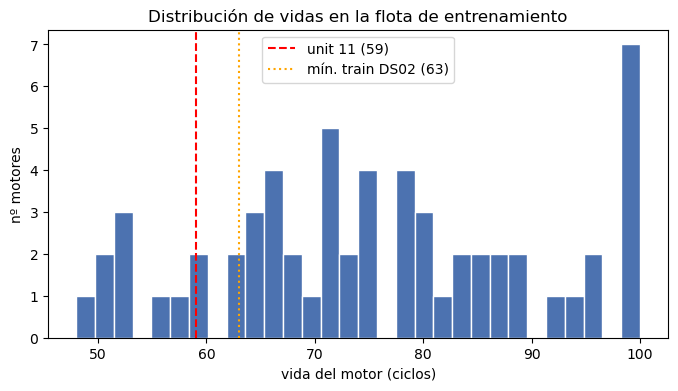

In [11]:
# ¿Cubre ahora la flota la vida de la unit 11 (59 ciclos)?
lifespans = np.array(lifespans)
print(f'Vidas en la flota de entrenamiento: min={lifespans.min()}, max={lifespans.max()}, '
      f'media={lifespans.mean():.0f}, n_motores={len(lifespans)}')
print(f'Motores con vida < 59 (como la unit 11): {(lifespans < 59).sum()}')
print(f'Motores con vida <= 63 (antes el mínimo en train DS02): {(lifespans <= 63).sum()}')
plt.figure(figsize=(8,4))
plt.hist(lifespans, bins=30, color='#4C72B0', edgecolor='white')
plt.axvline(59, color='red', ls='--', label='unit 11 (59)')
plt.axvline(63, color='orange', ls=':', label='mín. train DS02 (63)')
plt.xlabel('vida del motor (ciclos)'); plt.ylabel('nº motores'); plt.legend()
plt.title('Distribución de vidas en la flota de entrenamiento'); plt.show()

## 4. Conjunto de test: DS02 (units 11, 14, 15)

Para que el re-test sea **comparable con la Fase 1**, evaluamos sobre los mismos motores de
test de DS02. La unit 11 es la protagonista. (DS02 dev sí está en el entrenamiento, así que
`ds_code` de DS02 es conocido por el modelo.)

In [12]:
assert os.path.exists(FILES['DS02']), 'Necesito DS02 para el re-test de la unit 11'
df_test, _, _ = load_subset(FILES['DS02'], 'test', 'DS02')
cyc_test = cycle_level_features(df_test, SENSORS)
test = assemble(df_test, cyc_test, SENSORS, WVARS, subsample=None)
print('Test DS02:', sorted(test.unit.unique()), '|', len(test), 'obs')

Test DS02: [np.int64(11), np.int64(14), np.int64(15)] | 1253743 obs


## 5. Entrenamiento (mismo XGBoost y cap que la Fase 1)

In [13]:
# Cap del RUL (igual que el baseline congelado)
y_train_full = np.minimum(train['RUL'].values, RUL_CAP)

# Validación por motor (early stopping): apartamos algunos engine_id de la flota
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
tr_idx, es_idx = next(gss.split(train, y_train_full, train['engine_id']))
X_tr = train.iloc[tr_idx][FEATURES].values;  y_tr = y_train_full[tr_idx]
X_es = train.iloc[es_idx][FEATURES].values;  y_es = y_train_full[es_idx]

base_params = dict(n_estimators=600, learning_rate=0.05, max_depth=6,
                   subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                   reg_lambda=1.0, reg_alpha=0.1, random_state=SEED, n_jobs=-1,
                   importance_type='gain', eval_metric='rmse', early_stopping_rounds=30)

print('Entrenando sobre la flota...'); t0 = time.time()
model = xgb.XGBRegressor(**base_params)
model.fit(X_tr, y_tr, eval_set=[(X_es, y_es)], verbose=False)
print(f'  OK ({time.time()-t0:.0f}s) | best_iteration={model.best_iteration}')

Entrenando sobre la flota...
  OK (369s) | best_iteration=140


## 6. Re-test de la unit 11: ¿baja el sesgo?

Comparamos contra el RUL real **también capado** (para ser justos con el cap). El número clave
es el **sesgo de la unit 11**: en Fase 1 (solo DS02) era **+9,28** con cap=57 (y +11,22 sin
cap). Si con la flota baja, la hipótesis de las vidas cortas queda confirmada.

In [14]:
def aggregate(model, mat):
    p = model.predict(mat[FEATURES].values)
    t = mat[['unit', 'cycle', 'RUL']].copy(); t['pred'] = p
    g = t.groupby(['unit', 'cycle']).agg(RUL_real=('RUL','first'),
                                         RUL_med=('pred','median')).reset_index()
    g['RUL_real_cap'] = np.minimum(g.RUL_real, RUL_CAP)
    return g

g = aggregate(model, test)
print('Re-test DS02 con la flota (cap=%d):' % RUL_CAP)
print(f'{"unit":>5} {"vida":>5} {"RMSE":>7} {"MAE":>7} {"sesgo":>7}   (Fase1 sesgo cap57)')
ref = {11: '+9.28', 14: 'n/d', 15: 'n/d'}
for u in sorted(g.unit.unique()):
    s = g[g.unit == u]
    rmse = mean_squared_error(s.RUL_real_cap, s.RUL_med) ** .5
    mae  = mean_absolute_error(s.RUL_real_cap, s.RUL_med)
    sesgo = (s.RUL_med - s.RUL_real_cap).mean()
    print(f'{u:>5} {len(s):>5} {rmse:>7.2f} {mae:>7.2f} {sesgo:>+7.2f}   (ref u11 {ref.get(u,"")})')

rmse_glob = mean_squared_error(g.RUL_real_cap, g.RUL_med) ** .5
print(f'\nRMSE test agregado (flota, cap=57): {rmse_glob:.2f}   |   Fase 1 (solo DS02, cap=57): 7.94')

Re-test DS02 con la flota (cap=57):
 unit  vida    RMSE     MAE   sesgo   (Fase1 sesgo cap57)
   11    59    9.39    8.13   +7.97   (ref u11 +9.28)
   14    76    7.72    6.22   -5.00   (ref u11 n/d)
   15    67    5.74    4.45   -2.27   (ref u11 n/d)

RMSE test agregado (flota, cap=57): 7.69   |   Fase 1 (solo DS02, cap=57): 7.94


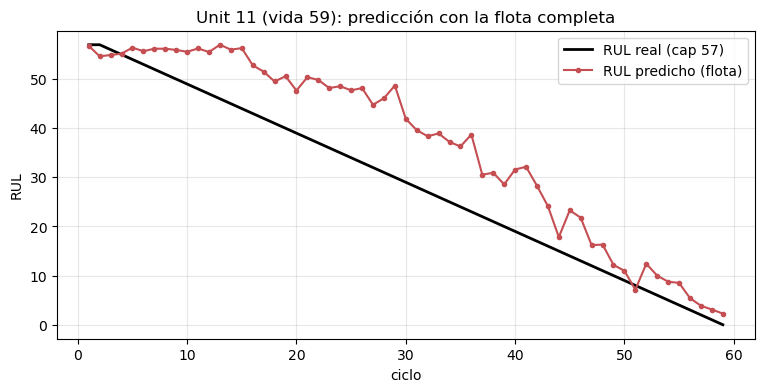

In [15]:
# Visual: trayectoria de RUL de la unit 11, flota vs real
s = g[g.unit == 11].sort_values('cycle')
plt.figure(figsize=(9,4))
plt.plot(s.cycle, s.RUL_real_cap, 'k-', lw=2, label='RUL real (cap 57)')
plt.plot(s.cycle, s.RUL_med, 'o-', ms=3, color='#C44E52', label='RUL predicho (flota)')
plt.title('Unit 11 (vida 59): predicción con la flota completa'); plt.xlabel('ciclo'); plt.ylabel('RUL')
plt.legend(); plt.grid(alpha=.3); plt.show()

## 7. Resultados obtenidos y lectura del experimento

**La flota de entrenamiento cambia el mapa:** 60 motores con vidas entre 48 y 100 ciclos
(media 76). Ahora hay **8 motores con vida menor que la unit 11** (59) — el modelo ya ha visto
motores que fallan tan pronto, que era exactamente lo que le faltaba en la Fase 1.

**Re-test de DS02 con el modelo de flota (cap=57):**

| Unit | Vida | RMSE | Sesgo | (Fase 1) |
|---|---|---|---|---|
| 11 | 59 | 9,39 | **+7,97** | +9,28 |
| 14 | 76 | 7,72 | −5,00 | — |
| 15 | 67 | 5,74 | −2,27 | — |

Dos lecturas: (1) **el sesgo de la unit 11 baja** (+9,28 → +7,97) al ver la flota más vidas
cortas — la dirección esperada, aunque no desaparece: sigue siendo el caso difícil; (2) el RMSE
agregado de DS02 mejora ligeramente respecto a la Fase 1 (7,69 vs 7,94), **sin haber entrenado
específicamente para DS02**: la variedad ayuda, no estorba.

**Chequeo de sobreajuste:** train 2,08 / validación 6,65 / test 7,69. Val ≈ test: el modelo está
sano, memoriza poco y lo que mide la validación es lo que se obtiene fuera.

**Siguiente paso:** evaluar sobre los test de TODOS los subconjuntos (no solo DS02) y comparar
modelo único vs especialistas por familia — notebooks `Fase2b` y `Fase2c`.

In [16]:
def eval_split(df_split, label):
    p = model.predict(df_split[FEATURES].values)
    t = df_split[['engine_id', 'cycle', 'RUL']].copy()
    t['pred'] = p; t['real'] = np.minimum(t.RUL, RUL_CAP)
    gg = t.groupby(['engine_id', 'cycle']).agg(real=('real', 'first'),
                                               pred=('pred', 'median')).reset_index()
    rmse = mean_squared_error(gg.real, gg.pred) ** .5
    print(f'{label}: RMSE={rmse:5.2f}  (n_ciclos={len(gg)})')

eval_split(train.iloc[tr_idx], 'TRAIN     ')
eval_split(train.iloc[es_idx], 'VALIDACIÓN')
print(f'TEST DS02 : RMSE={rmse_glob:5.2f}')

TRAIN     : RMSE= 2.08  (n_ciclos=3835)
VALIDACIÓN: RMSE= 6.65  (n_ciclos=700)
TEST DS02 : RMSE= 7.69
